In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy


**H2GCN**

In [ ]:

class H2GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, num_layers, dropout_rate = 0.5):
        super().__init__()

        self.K = num_layers
        # self.A = A  # adjacency matrix (no self loops)
        # self.n = A.shape[0]

        # # Precompute adjacency matrices
        # self.A1 = self.normalize(A)  # 1-hop
        # self.A2 = self.compute_A2(A)  # 2-hop (cleaned)

        # Feature embedding (S1)
        self.embed = nn.Linear(in_dim, hidden_dim)
        self.dropout = nn.Dropout(p = dropout_rate)

        # Final classifier
        final_dim = (2 ** (num_layers + 1) - 1) * hidden_dim
        self.classifier = nn.Linear(final_dim, num_classes)

    def normalize(self, A):
        """Symmetric normalization"""
        deg = A.sum(dim=1)
        deg_inv_sqrt = torch.pow(deg + 1e-8, -0.5)
        D_inv_sqrt = torch.diag(deg_inv_sqrt)
        return D_inv_sqrt @ A @ D_inv_sqrt

    def compute_A2(self, A):
        """Compute clean 2-hop adjacency"""
        A2 = A @ A

        # Remove self and 1-hop
        I = torch.eye(A.shape[0], device=A.device)
        A2 = A2 - A - I

        # Binarize
        A2 = (A2 > 0).float()

        # Normalize
        return self.normalize(A2)
    
    def edge_index_to_adj(edge_index, num_nodes):
        A = torch.zeros((num_nodes, num_nodes), device=edge_index.device)
        A[edge_index[0], edge_index[1]] = 1
        return A

    def forward(self, X, edge_index):
        """
        X: (n, in_dim)
        """
        n = X.size(0)

        # Build Adjacency for this Batch
        A = torch.zeros((n,n), device= X.device)
        A[edge_index[0], edge_index[1]] = 1

        # Compute A1 & A2 locally
        A1 = self.normalize(A)
        A2 = self.compute_A2(A)


        # S1: initial embedding
        r0 = F.relu(self.embed(X))  # (n, p)
        r0 = self.dropout(r0)
        representations = [r0]
        r_prev = r0

        # S2: propagation layers
        for k in range(self.K):

            # 1-hop aggregation
            h1 = A1 @ r_prev  # (n, d)

            # 2-hop aggregation
            h2 = A2 @ r_prev  # (n, d)

            # Concatenate (D2)
            r_k = torch.cat([h1, h2], dim=1)  # (n, 2d)
            r_k = self.dropout(r_k)

            representations.append(r_k)
            r_prev = r_k  # move to next layer

        # S3: final combination (D3)
        r_final = torch.cat(representations, dim=1)
        r_final = self.dropout(r_final)

        out = self.classifier(r_final)

        return out

**MixHop**

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHopGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, num_hops=2, dropout=0.5):
        super().__init__()

        self.num_hops = num_hops
        self.dropout = nn.Dropout(dropout)

        # MLP after concatenation
        self.mlp = nn.Sequential(
            nn.Linear((num_hops + 1) * in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def normalize(self, A):
        deg = A.sum(dim=1)
        deg_inv_sqrt = torch.pow(deg + 1e-8, -0.5)
        D_inv_sqrt = torch.diag(deg_inv_sqrt)
        return D_inv_sqrt @ A @ D_inv_sqrt

    def forward(self, X, edge_index):
        n = X.size(0)

        # Build adjacency
        A = torch.zeros((n, n), device=X.device)
        A[edge_index[0], edge_index[1]] = 1

        A_norm = self.normalize(A)

        # Compute multi-hop features
        features = [X]
        X_k = X

        for _ in range(self.num_hops):
            X_k = A_norm @ X_k
            features.append(X_k)

        # Concatenate all hops
        H = torch.cat(features, dim=1)

        H = self.dropout(H)

        out = self.mlp(H)

        return out

In [3]:
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import ClusterData, ClusterLoader

dataset = Planetoid(root = "data", name= "cora")
data = dataset[0]

# cluster_data = ClusterData(data, num_parts=1000)
# loader = ClusterLoader(cluster_data, batch_size=5)
data

/home/gowrav8849/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [24]:
def train(model, data, optimizer):
  model.train()
  optimizer.zero_grad()
  out = model(data.x, data.edge_index)
  loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
  loss.backward()
  optimizer.step()

  return loss.item()

def evaluate(model, data):
  model.eval()
  out = model(data.x, data.edge_index)
  pred = out.argmax(dim = 1)
  correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
  return correct / data.test_mask.sum().item()

In [25]:
model = H2GCN(
  in_dim= data.num_features,
  hidden_dim=32,
  num_classes=len(data.y.unique()),
  num_layers=2
)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

for epoch in range(10):
  loss = train(model, data, optimizer)
  print(f"Epoch {epoch} || Loss : {loss}")
  acc = evaluate(model, data)
  print("accuracy :",acc )

Epoch 0 || Loss : 1.94769287109375
accuracy : 0.309
Epoch 1 || Loss : 1.8668731451034546
accuracy : 0.365
Epoch 2 || Loss : 1.7104028463363647
accuracy : 0.487
Epoch 3 || Loss : 1.4717603921890259
accuracy : 0.605
Epoch 4 || Loss : 1.179395079612732
accuracy : 0.704
Epoch 5 || Loss : 0.8958622813224792
accuracy : 0.753
Epoch 6 || Loss : 0.6514431834220886
accuracy : 0.782
Epoch 7 || Loss : 0.4251505732536316
accuracy : 0.791
Epoch 8 || Loss : 0.26665547490119934
accuracy : 0.788
Epoch 9 || Loss : 0.17539913952350616
accuracy : 0.797


**Texas/Cornell/Wisconsin Datasets**

In [6]:
from torch_geometric.datasets import WebKB
from torch_geometric.transforms import NormalizeFeatures

torch.manual_seed(42)

In [7]:
transform = NormalizeFeatures()
texas_data = WebKB(root = 'data', name = 'Texas', transform= transform)[0]
cornell_data = WebKB(root = 'data', name = 'Cornell', transform= transform)
wisconsin_data = WebKB(root = 'data', name = 'wisconsin', transform=transform)

### Data Processing

In [8]:
print(texas_data)

Data(x=[183, 1703], edge_index=[2, 325], y=[183], train_mask=[183, 10], val_mask=[183, 10], test_mask=[183, 10])


**Homophily**

In [9]:
y = texas_data.y
edge_index = texas_data.edge_index
same = 0
for i in range(edge_index.shape[1]):
  u = edge_index[0, i]
  v = edge_index[1, i]
  
  if y[u] == y[v]:
    same += 1

homoplily = same / edge_index.shape[1]

print("texas Data features shape:",texas_data.x.shape) 
print("Labels: ",texas_data.y.unique())
print("Homophily: ", homoplily)


texas Data features shape: torch.Size([183, 1703])
Labels:  tensor([0, 1, 2, 3, 4])
Homophily:  0.1076923076923077


In [10]:
train_masks = [] # appended all train split mask on this
test_masks = []
val_masks = []

train_mask_len = []
test_mask_len = []
val_mask_len = []

for _ in range(texas_data.train_mask.shape[1]):
  train_masks.append(texas_data.train_mask[:, _])
  test_masks.append(texas_data.test_mask[:,_])
  val_masks.append(texas_data.val_mask[:, _])
  train_mask_len.append(len(train_masks[_][train_masks[_]]))
  test_mask_len.append(len(test_masks[_][test_masks[_]]))
  val_mask_len.append(len(val_masks[_][val_masks[_]]))
print("train_mask_len:", train_mask_len)
print("val_mask_len:", val_mask_len)
print("test_mask_len:", test_mask_len)
print("total nodes:", train_mask_len[0]+test_mask_len[0]+val_mask_len[0])

train_mask_len: [87, 87, 87, 87, 87, 87, 87, 87, 87, 87]
val_mask_len: [59, 59, 59, 59, 59, 59, 59, 59, 59, 59]
test_mask_len: [37, 37, 37, 37, 37, 37, 37, 37, 37, 37]
total nodes: 183


In [11]:
texas_data.x[train_masks[0]]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

### Training on texas  data

In [12]:
texas_data.num_features

1703

In [26]:
def train(model, data, train_mask, optimizer):
  model.train()
  optimizer.zero_grad()
  out = model(data.x, data.edge_index)
  loss = F.cross_entropy(out[train_mask], data.y[train_mask])
  loss.backward()
  optimizer.step()
  return loss.item()

def evaluate(model, data, val_mask):
  model.eval()
  out = model(data.x, data.edge_index)
  pred = out.argmax(dim = 1)
  correct = (pred[val_mask] == data.y[val_mask]).sum().item()
  return correct/ val_mask.sum().item()

def evaluate_loss(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[mask], data.y[mask])
    return loss.item()


In [ ]:
all_acc = []

num_splits = texas_data.train_mask.shape[1]

for i in range(num_splits):

    print(f"\n Training on split {i}")

    model = H2GCN(
        in_dim=texas_data.num_features,
        hidden_dim=32,
        num_classes=len(texas_data.y.unique()),
        num_layers=2
    )
    # model = MultiHopGNN(
    #     in_dim = texas_data.num_features,
    #     hidden_dim=32,
    #     num_classes=len(texas_data.y.unique())
    # )
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,              # ← better than 1e-3 for H2GCN
        weight_decay=5e-4
    )

    train_mask = texas_data.train_mask[:, i]
    val_mask   = texas_data.val_mask[:, i]
    test_mask  = texas_data.test_mask[:, i]

    # Early stopping setup
    best_val_loss = float('inf')
    patience = 100
    patience_counter = 0
    best_state = None

    for epoch in range(2000):

        train_loss = train(model, texas_data, train_mask, optimizer)
        val_loss = evaluate_loss(model, texas_data, val_mask)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    # Restore best model
    model.load_state_dict(best_state)

    # Final evaluation
    acc = evaluate(model, texas_data, test_mask)
    print(f"Test Accuracy (split {i}): {acc:.4f}")

    all_acc.append(acc)


# ---------- FINAL RESULT ----------
print("\nFinal Average Accuracy:", sum(all_acc) / len(all_acc))


 Training on split 0
Epoch 0 | Train Loss: 2.7238 | Val Loss: 5.1112
Epoch 50 | Train Loss: 0.6753 | Val Loss: 11.8636
Epoch 100 | Train Loss: 0.5916 | Val Loss: 12.5956
⏹ Early stopping at epoch 100
Test Accuracy (split 0): 0.6216

 Training on split 1
Epoch 0 | Train Loss: 2.6356 | Val Loss: 6.3263
Epoch 50 | Train Loss: 0.8413 | Val Loss: 5.1999
Epoch 100 | Train Loss: 0.6859 | Val Loss: 3.9657
Epoch 150 | Train Loss: 0.6243 | Val Loss: 6.0138
Epoch 200 | Train Loss: 0.6652 | Val Loss: 7.0666
⏹ Early stopping at epoch 212
Test Accuracy (split 1): 0.5946

 Training on split 2
Epoch 0 | Train Loss: 3.2085 | Val Loss: 6.5674
Epoch 50 | Train Loss: 1.0322 | Val Loss: 2.6318
Epoch 100 | Train Loss: 0.7197 | Val Loss: 2.0655
⏹ Early stopping at epoch 122
Test Accuracy (split 2): 0.4865

 Training on split 3
Epoch 0 | Train Loss: 4.6480 | Val Loss: 3.6687
Epoch 50 | Train Loss: 0.9242 | Val Loss: 3.1049
Epoch 100 | Train Loss: 0.8584 | Val Loss: 3.8772
⏹ Early stopping at epoch 101
Test A

In [97]:
losses[0]
losses[1]
losses[2]

6.023666858673096

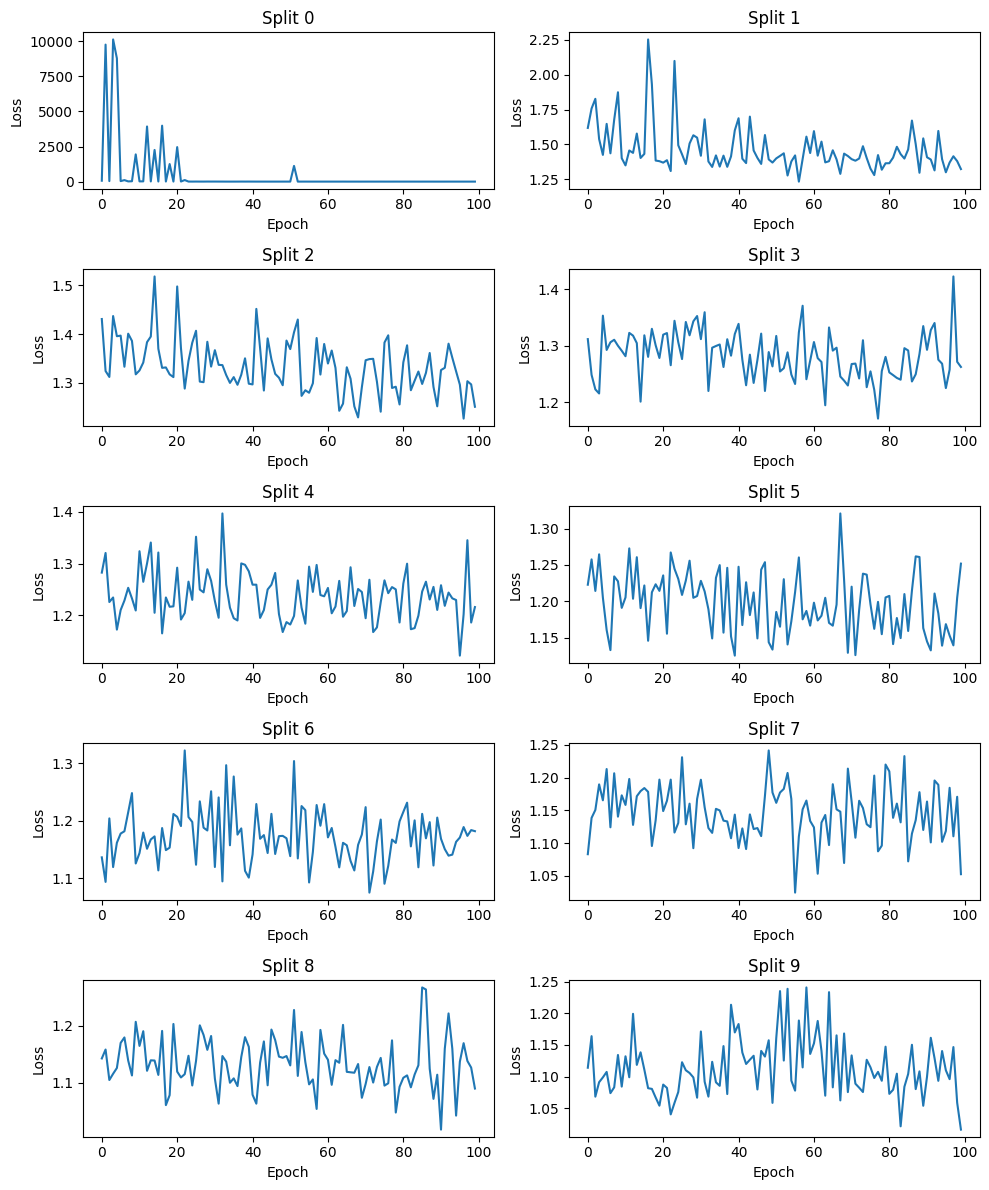

In [ ]:
import matplotlib.pyplot as plt

splits = [1,2,3,4,5,6,7,8,9,10]

fig, axes = plt.subplots(5, 2, figsize=(10, 12))  # 5 rows, 2 cols
axes = axes.flatten()  # make indexing easy

start = 0

for idx, end in enumerate(splits):
    axes[idx].plot(losses[start:end])
    axes[idx].set_title(f"Split {idx}")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("Loss")
    
    start = end

plt.tight_layout()
plt.show()

### Training on Wisconsin Data

In [31]:
from torch_geometric.datasets import WebKB

# Load dataset
dataset = WebKB(root='data', name='wisconsin')

# Get single graph
data = dataset[0]

print(data)

Data(x=[251, 1703], edge_index=[2, 515], y=[251], train_mask=[251, 10], val_mask=[251, 10], test_mask=[251, 10])


In [36]:
all_acc = []

num_splits = texas_data.train_mask.shape[1]

for i in range(num_splits):

    print(f"\n Training on split {i}")

    # model = H2GCN(
    #     in_dim=texas_data.num_features,
    #     hidden_dim=32,
    #     num_classes=len(texas_data.y.unique()),
    #     num_layers=2
    # )
    model = MultiHopGNN(
        in_dim = texas_data.num_features,
        hidden_dim=32,
        num_classes=len(texas_data.y.unique())
    )
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,              # ← better than 1e-3 for H2GCN
        weight_decay=5e-4
    )

    train_mask = texas_data.train_mask[:, i]
    val_mask   = texas_data.val_mask[:, i]
    test_mask  = texas_data.test_mask[:, i]

    # Early stopping setup
    best_val_loss = float('inf')
    patience = 100
    patience_counter = 0
    best_state = None

    for epoch in range(200):

        train_loss = train(model, texas_data, train_mask, optimizer)
        val_loss = evaluate_loss(model, texas_data, val_mask)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    # Restore best model
    model.load_state_dict(best_state)

    # Final evaluation
    acc = evaluate(model, texas_data, test_mask)
    print(f"Test Accuracy (split {i}): {acc:.4f}")

    all_acc.append(acc)


# ---------- FINAL RESULT ----------
print("\nFinal Average Accuracy:", sum(all_acc) / len(all_acc))


 Training on split 0
Epoch 0 | Train Loss: 4.1588 | Val Loss: 4.8770
Epoch 50 | Train Loss: 1.0388 | Val Loss: 10.1414
Epoch 100 | Train Loss: 0.6495 | Val Loss: 9.3151
Early stopping at epoch 101
Test Accuracy (split 0): 0.1622

 Training on split 1
Epoch 0 | Train Loss: 3.2401 | Val Loss: 8.5967
Epoch 50 | Train Loss: 0.7939 | Val Loss: 3.4747
Epoch 100 | Train Loss: 1.8675 | Val Loss: 4.3629
Early stopping at epoch 135
Test Accuracy (split 1): 0.5946

 Training on split 2
Epoch 0 | Train Loss: 3.4920 | Val Loss: 5.7626
Epoch 50 | Train Loss: 0.7175 | Val Loss: 3.1771
Epoch 100 | Train Loss: 0.6253 | Val Loss: 5.7355
Early stopping at epoch 123
Test Accuracy (split 2): 0.4595

 Training on split 3
Epoch 0 | Train Loss: 3.8754 | Val Loss: 5.0174
Epoch 50 | Train Loss: 0.7697 | Val Loss: 3.2061
Epoch 100 | Train Loss: 0.7715 | Val Loss: 3.5560
Early stopping at epoch 137
Test Accuracy (split 3): 0.6757

 Training on split 4
Epoch 0 | Train Loss: 2.6177 | Val Loss: 14.4669
Epoch 50 | T